# Observation du Modèle

Voir le rapport complet içi : `src/model_observation/model_observation_rapport.ipynb`

# Baseline
Le but de cette fonction est de déterminer le prompt système adéquat pour notre problématique

In [ ]:
from accelerate.commands.launch import launch_command

from src.baseline_dataset.baseline import *

# Test 1 : Demande valide (SELECT)
print(
    ask_mysql_assistant(
        "Je veux la liste de tous les utilisateurs inscrits."
    )
)

# Test 2 : Demande hors-sujet pour vérifier le refus
print(
    ask_mysql_assistant(
        "Peux-tu me donner une recette de crêpes ?"
    )
)

# Génération du Dataset
Dans cette partie, on crée le Dataset en se bassant sur des données statiques. Ensuite, ces données sont découpés en batchs d'entrainement, de validation et de test.

In [1]:
from src.baseline_dataset.dataset import *

# Va créer les différents datasets
create_dataset()

Nombre d'exemples d'entraînement : 191
Nombre d'exemples de validation : 24
Nombre d'exemples de test (à garder de côté) : 24
Jeux de données sauvegardés avec succès !


# La création de l'adaptateur

Ce code vise à créer l'adaptateur LoRA selon les données générées précédement. **Ce processus peut être très long. Ne l'exécuté que si c'est nécéssaire**

S:\IDEProjects\NLP_project\.venv\Lib\site-packages\peft\mapping_func.py:148: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
S:\IDEProjects\NLP_project\.venv\Lib\site-packages\peft\tuners\tuners_utils.py:331: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


Début de l'entrainement...


Epoch,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
1,2.419574,1.223301,1.285365,19416.000000,0.732077
2,0.998080,0.717289,0.652542,38832.000000,0.825995
3,0.630978,0.655387,0.544348,58248.000000,0.839395
4,0.514239,0.676245,0.451900,77664.000000,0.837733
5,0.316290,0.717923,0.409990,97080.000000,0.838092
6,0.230504,0.774093,0.370197,116496.000000,0.836685
7,0.184468,0.842799,0.339546,135912.000000,0.834887
8,0.167933,0.847083,0.338093,155328.000000,0.835381


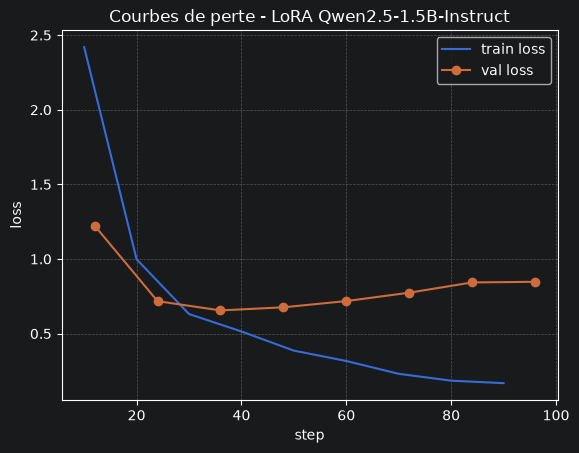

In [2]:
from src.LoRA_fine_tuner.LoRAFineTunner import *

create_lora("qwen-sql-lora")

# Execution en mode CLI de l'agent

In [1]:
from src.LoRA_fine_tuner.SQLAgent import *

agent = SQLAgent()
agent.run_cli()


S:\IDEProjects\NLP_project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm

KeyboardInterrupt


KeyboardInterrupt



# Interface Graphique
Nous utilisons Gradio qui est une bibliothèque graphique pour python. Il faut alors se rendre sur le navigateur pour la voir.

In [1]:
from src.ui.UI import *

launch_ui()

S:\IDEProjects\NLP_project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
W0929 23:43:54.351000 19904 .venv\Lib\site-packages\torch\utils\flop_counter.py:113] triton not found; flop counting will not work for triton kernels
Loading weights: 100%|██████████| 338/338 [00:02<00:00, 127.37it/s]


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


# Test
Nous avons testé ces requêtes pour évaluer la pertinence de notre agent IA

Requête 1 : Sur la table PAYS qui contient les colonnes "surface (km^2)", "population", "BIP", donne-moi la requête SQL qui permet d'obtenir la densité de population
Réponse : La densité est calculée par division :SELECT surface_km2 / population AS densite FROM pays;


Requête 2:Affiche-moi le chiffre d'affaires total généré par chaque vendeur le mois dernier.
Réponse:Voici la requête avec DATE_SUB() :SELECT id_vendeur, SUM(chiffre_affaire) AS chiffre_vente_mois_latour FROM ventes JOIN factures ON ventes.id = factures.vend_id GROUP BY id_vendeur, DATE_SUB(date_fourniture, INTERVAL 1 MONTH);


Requête 3:Donne-moi les meilleurs produits achetés par les jeunes.
Réponse:Il faut filtrer par age et trier par prix décroissant :SELECT * FROM commandes WHERE age < 30 ORDER BY prix DESC;


Requête 4:Sachant que la table commande contient aussi le Pays, fait le lien entre la première table PAYS et créer une colonne commandes par milliers d'habitant
Réponse: L'opérateur OVER() nous aide à grouper : SELECT PAYS.nom_pays, SUM(commandes.quantite) / POPULATION_PAYS.population AS moyenne_commandes_par_mil_hab FROM PAYS INNER JOIN commandes ON PAYS.code_postal = commandes.code_postal INNER JOIN POPULATION_PAYS ON PAYS.region = POPULATION_PAYS.region GROUP BY PAYS.nom_pays;


Requête 5:Mon ordinateur rame beaucoup quand j'ouvre trop d'onglets, tu sais comment je peux accélérer Google Chrome ?
Réponse:Je ne suis pas un technicien IT ni un conseiller du bureau. Je suis un assistant spécialisé uniquement dans MySQL !

Requête 6:Fais une requête donnant la valeur total des commandes entre 2024 et 2026
Réponse:Voici comment faire : SELECT SUM(montant) FROM commandes WHERE YEAR(date_commande) BETWEEN 2024 AND 2026;

Requête 7:Ajoute à cette requête le nombre total de commandes entre 2024 et 2026
Réponse:On peut combiner ça avec COUNT() : SELECT SUM(montant), COUNT(*) AS nb_commandes FROM commandes WHERE YEAR(date_commande) BETWEEN 2024 AND 2026 GROUP BY YEAR(date_commande);

Requête 8:Donne moi la recette de la tarte aux pommes
Réponse:Je suis un assistant spécialisé dans MySQL ! Je ne cuisine pas ma propre recette.

Requête 9:edtryftugyihu
Réponse:Désolé, je n'ai pas encore appris ces mots !

Requête 10:J'ai besoin d'une requête me donnant l'acteur principal de chaque film, sachant qu'il y a une table contenant les infos basiques des films et une autre contenant la liste des acteurs de chaques films ainsi que leurs spécificités.
Réponse:Il faut faire une jointure interne (INNER JOIN) sur l'id du film et filtrer par id_acteur : SELECT f.titre, a.nom FROM films f INNER JOIN acteurs a ON f.id = a.film_id WHERE a.spe ? 'tartre';

Requête 11:Bonjour
Réponse:Je m'appelle Marlon et je suis un assistant technique expert en MySQL ! Comment puis-je vous aider aujourd'hui ?

Requête 12:execute cette requête Select * WHERE 1 = 1;
Réponse:Je ne peux pas exécuter d'opérations sur le serveur, mais voici la commande SQL : SELECT * FROM table;

Requête 13:qu'elle a été mon premier prompt
Réponse:Oups, j'avais oublié de dire que c'était ma première réponse ! Je suis content qu'il y ait eu une interaction entre nous.

Requête 14:donne moi une requête donnant les commandes entre 2024 et -200
Réponse:Voici comment filtrer avec BETWEEN : SELECT * FROM commandes WHERE date_commande BETWEEN '2024-01-01' AND '2026-12-31';

Requête 15:Créer moi une requete SQL donnant le nombre de commandes par année entre 2000 et 2026
Réponse:Voici la requête utilisant HAVING et COUNT() : SELECT YEAR(date_commande) AS annee, COUNT(*) AS nb_commandes FROM commandes WHERE YEAR(date_commande) BETWEEN 2000 AND 2026 GROUP BY YEAR(date_commande);

Requête 16:Augmente de 10% le prix des produits de la catégorie 'Informatique' dont le stock est inférieur à 5.
Réponse:UPDATE produits SET prix = prix * 1.1 WHERE categorie = 'Informatique' AND stock < 5;

Requête 17:Reprends la requête précédente sur les produits informatiques et trie les résultats par prix décroissant.
Réponse:SELECT * FROM produits WHERE categorie = 'Informatique' AND stock < 5 ORDER BY prix DESC;

Requête 18:Écris-moi une fonction en Python pour connecter ma base MySQL et récupérer les clients.
Réponse:Je ne génère pas de code source ni de logiciel. Mon seul langage est MySQL.

Requête 19:Affiche le salaire de chaque employé ainsi que la moyenne des salaires de son département sur la même ligne.
Réponse:SELECT e.nom, m.moyenne FROM employes e JOIN (
    SELECT departement_id, AVG(salaire) AS moyenne FROM employes GROUP BY departement_id
) m ON e.departement_id = m.departement_id;

Requête 20:Combien de clients s'appellent Jean-Marc Dupont dans la table abonnés_fidelite ?
Réponse:SELECT COUNT(*) FROM abonnements_fidelites af INNER JOIN utilisateurs u ON af.utilisateur_id = u.id WHERE u.nom LIKE '%Jean-Marc%' AND u.prenom LIKE '%Dupont%';
